<a href="https://colab.research.google.com/github/GustavoFA/IA368/blob/main/notebooks/LM_self_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA368 - HH

## Activity 2 - Language Model with Self-Attention


Gustavo Freitas Alves

236249

---
### Imports

In [ ]:
import os
import re

import math

import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from collections import Counter

from tqdm import tqdm

from sklearn.model_selection import train_test_split

---
### Data : Preprocessing


Cloning repository

In [ ]:
!git clone -q https://github.com/ethelbeluzzi/projetomachado

In [ ]:
DATA_PATH = r'projetomachado/textonormalizado1000.txt'

#### Analyzing the data in the text

In [ ]:
# Obtaining the character from the text
characters = None
lines = None

with open(DATA_PATH, 'r') as text:
  # characters = text.read()
  lines = text.readlines()
# checking number of characters in the text
if characters is not None: print(f'Number of characters: {len(characters)}')
# checking number of lines in the text
if lines is not None: print(f'Number of lines: {len(lines)}')

In [ ]:
if lines:
  print(f'{lines[200]=}')

lines[200]='página da Ilíada. Desta vez, a Vênus da situação saiu ferida do combate; um estalo rebentara no\n'


#### Separating words and punctuation marks that are important for understanding the text

In [ ]:
# Data cleaning - remove \n and spaces
# Therefore, we'll keep words (incuding accents), punctuation marks, numbers and symbols
# I'll keep upper and lower case differences
# \w+ = alpahnumeric characters and underscores (one or more)
# ^\w\s = punctuations and symbols
# UNICODE -> allows accented letters (as well as Greek letters and others)
filter_lines = [re.findall(r'\w+|[^\w\s]', line, flags=re.UNICODE) for line in lines]

In [ ]:
def count_words(text):
  # class for count words
  word_counts = Counter()
  for words in text:
    # just get the words for counting
    word_counts.update(words)
  return word_counts


Checking the words count for the whole text

In [ ]:
full_text = count_words(filter_lines)

In [ ]:
full_text.most_common(10)

[(',', 305962),
 ('.', 246961),
 ('a', 117877),
 ('que', 115658),
 ('de', 106619),
 ('e', 95157),
 ('o', 87822),
 (';', 53899),
 ('não', 48103),
 ('do', 39408)]

#### Separating the data into training and validation, in a 20/80 ratio

In [ ]:
# data_ratio = 0.05
data_ratio = 1
val_ratio = 0.2

In [ ]:
%%time
lines_train, lines_val = train_test_split(
    filter_lines[:int(data_ratio * len(filter_lines))],
    test_size=val_ratio,
    random_state=18, # deterministic division
    shuffle=True # same seen
)

CPU times: user 90.9 ms, sys: 4.99 ms, total: 95.8 ms
Wall time: 96 ms


In [ ]:
words_count_train = count_words(lines_train)
# words_count_train.most_common(10)

#### Saving the training and validation set

In [ ]:
# # I didn't use it :/ -- I didn't see many advantage in saving my finished dataset
# torch.save(lines_train, f'lines_train_{data_ratio}.pt')
# torch.save(lines_val, f'lines_val_{val_ratio}.pt')

#### Checking the data after processing

In [ ]:
lines_train[20]

['Da', 'nossa', 'dor', 'eternamente', 'acaba', ',']


Counting the number of words

In [ ]:
print(f'Number of words in the training text: {sum([len(line) for line in lines_train])}')
print(f'Number of words in the validation text: {sum([len(line) for line in lines_val])}')

#### Loading dataset

In [ ]:
# # I didn't use it
# train_path = r''
# val_path = r''

# lines_train = torch.load(train_path)
# lines_val = torch.load(val_path)

---
### Vocabulary

In [ ]:
VOCAB_SIZE = 2000

In [ ]:
most_freq_words = [word for word, _ in words_count_train.most_common(VOCAB_SIZE)]
vocab = {word: idx for idx, word in enumerate(most_freq_words, 1)}

In [ ]:
def encoder(_sentence, _vocab=vocab):
  # enconde the words according to the vocabulary and the filtering applied previously
  # return [_vocab.get(word, 0) for word in re.findall(r'\w+|[^\w\s]', _sentence, flags=re.UNICODE)]
  return [_vocab.get(word, 0) for word in _sentence]

In [ ]:
# encoder('eu sou escritor')
encoder(['eu', 'sou', 'escritor'])

[37, 349, 0]

---
### Dataset

In [ ]:
class LanguageModelDataset(Dataset):
  def __init__(self, text, vocab):
    self.context_size = 5
    self.text = text
    self.vocab = vocab

    self.data = []

    for line in self.text:
      tokens = encoder(line, self.vocab)
      for i in range(self.context_size, len(tokens)):
        context = tokens[i-self.context_size:i]
        target = tokens[i]

        if 0 in context or target == 0:
          continue
        self.data.append((context, target))

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    context, target = self.data[idx]
    return torch.tensor(context), torch.tensor(target)

In [ ]:
%%time
train_dataset = LanguageModelDataset(lines_train, vocab)
val_dataset = LanguageModelDataset(lines_val, vocab)

CPU times: user 2.7 s, sys: 78.5 ms, total: 2.78 s
Wall time: 2.78 s


---
### DataLoader

In [ ]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#### Verificando os dados do DataLoader

In [ ]:
context, label = next(iter(train_loader))

In [ ]:
context[2], label[2]

(tensor([   2,  608,    1, 1227,  229]), tensor(23))

In [ ]:
# Dimensions
context.shape, label.shape

(torch.Size([64, 5]), torch.Size([64]))

In [ ]:
# Checking the last batch dimension
batches = list(train_loader)
last_context, last_target = batches[-1]
len(last_target)

32

In [ ]:
# Just checking how function expand() works
torch.arange(0, 5,device=context.device).unsqueeze(0).expand(32, 5)

tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]])

---
### Model

Self-Attention

In [ ]:
class SingleSelfAttention(nn.Module):
  """
     Self-Attention model (single head)
  """
  def __init__(self, d_model, _loop_version:bool=False, dropout:float=0.1):
    super().__init__()

    # Obtain the embeddings vector dimension
    self.d_model = d_model
    # select the operation
    self.loop_version = _loop_version

    # Linear projections
    # When starting the model, weights are created randomly
    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)
    self.W_o = nn.Linear(d_model, d_model)

    # Normalize layer
    self.norm = nn.LayerNorm(d_model)

    # Dropout layer of 0.1 (at the same of the article - 5.4 - Regularization)
    self.dropout = nn.Dropout(dropout)

  def forward_loop(self, x):
    """
      Loop implementation
    """
    batch_size, context_size, d_model = x.size()

    # Linear projections
    q = self.W_q(x)
    k = self.W_k(x)
    v = self.W_v(x)

    # Output
    out = torch.zeros_like(q)

    # scroll through the batch
    for b in range(batch_size):

      for c in range(context_size):
        scores = []
        for i in range(context_size):
          # Q * K / sqrt(d_k)
          score = (q[b,c] @ k[b,i] / (d_model ** 0.5))
          scores.append(score)
        # Softmax
        weights = F.softmax(torch.tensor(scores), dim=0)
        for j in range(context_size):
          # Softmax * V
          out[b,c] += weights[j] * v[b,j]

    out = self.W_o(out)
    # dropout
    out = self.dropout(out)

    # residual + norm
    return self.norm(x + out)

  def forward_matrix(self, x):
    """
      Matrix product implementation
    """

    Q = self.W_q(x)
    K = self.W_k(x)
    V = self.W_v(x)

    # scores = torch.tensor(scores, device=x.device, dtype=x.dtype)
    # Compute the output matrix - expression 1 of topic 3.2.1 - Scaled Dot-Product Attention
    # K : context, dmodel --> dmodel, context
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_model ** 0.5)
    # apply softmax on the last dimension
    weigths = F.softmax(scores, dim=-1)
    out = torch.matmul(weigths, V)

    # Linear layer
    out = self.W_o(out)
    # Dropout - 5.4 - Regularization
    out = self.dropout(out)
    # residual + normalization
    out = self.norm(x + out)

    return out

  def forward(self, x):
    if self.loop_version:
      return self.forward_loop(x)
    else:
      return self.forward_matrix(x)

Encoder : Self-Attention + FFN

In [ ]:
class LanguageModel(nn.Module):
  """
    Language model + self-attention + feed-forward network
  """

  def __init__(self, _loop_version:bool=False, vocab_size:int=VOCAB_SIZE+1, embed_dim:int=256):

    super().__init__()

    # embedding dimension
    self.d_model = embed_dim
    # vocab dimension
    self.vocab_size = vocab_size
    # context dimension
    self.context_len = 5

    hidden_dim = embed_dim * 2


    self.loop_version = _loop_version
    print(f'SELF-ATTENTION MODE = {"LOOP" if self.loop_version else "MATRIX"}')

    # tokens and position
    self.embedding = nn.Embedding(vocab_size, embed_dim)
    self.pos_embedding = nn.Embedding(self.context_len, embed_dim)

    # dropout (of 0.1) after the embeddings sum - according to the article
    self.dropout = nn.Dropout(0.1)

    # Self-Attention layer
    self.self_attention = SingleSelfAttention(embed_dim, self.loop_version)

    # 2 FFN layers
    self.mlp = nn.Sequential(
        # nonlinear layer (with ReLU)
        nn.Linear(embed_dim, hidden_dim),
        nn.ReLU(),
        # nonlinear
        nn.Linear(hidden_dim, embed_dim)
    )

    # normalization layer
    self.norm = nn.LayerNorm(embed_dim)

    # output layer - return to vocab dimension
    self.output = nn.Linear(embed_dim, vocab_size)

  def forward(self, x):
    batch_size, context_size = x.shape

    positions = torch.arange(0, context_size,device=x.device).unsqueeze(0).expand(batch_size, context_size)
    # the input value is affected by the feature vector and the position
    # Multiplication of embeddings  - 3.4 - Embeddings and Softmax
    x = self.embedding(x) * (self.d_model ** 0.5) + self.pos_embedding(positions)
    # Dropout - 5.4 - Regularization
    x = self.dropout(x)

    # Attention block
    attention_out = self.self_attention(x)
    # value to use on the residual connection
    x = attention_out

    # feed forward block
    mlp_out = self.mlp(attention_out)
    # output dropout
    mlp_out = self.dropout(mlp_out)
    # Residual + normalization
    mlp_out = self.norm(x + mlp_out)

    # output dimension = [batch_size, context_size, d_model]
    # logits of predicted token -> last token of context_size
    logits = self.output(mlp_out[:,-1,:]) # out = batch_size * embed_dim

    return logits


Defining device

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Defining model

In [ ]:
model = LanguageModel()
model

SELF-ATTENTION MODO = MATRICIAL


LanguageModel(
  (embedding): Embedding(2001, 256)
  (pos_embedding): Embedding(5, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (self_attention): SingleSelfAttention(
    (W_q): Linear(in_features=256, out_features=256, bias=True)
    (W_k): Linear(in_features=256, out_features=256, bias=True)
    (W_v): Linear(in_features=256, out_features=256, bias=True)
    (W_o): Linear(in_features=256, out_features=256, bias=True)
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=256, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output): Linear(in_features=256, out_features=2001, bias=True)
)

#### Checking model


Quick test of time and final result of each attention mode (matrix and loop)

In [ ]:
token_emb = nn.Embedding(VOCAB_SIZE+1, 128)
pos_emb = nn.Embedding(5, 128)

x = torch.randint(0, VOCAB_SIZE+1, (2, 5))
positions = torch.arange(5).unsqueeze(0).expand(2, 5)
x_emb = token_emb(x) * (128 ** 0.5) + pos_emb(positions)

In [ ]:
attention = SingleSelfAttention(128)
attention.eval()

SingleSelfAttention(
  (W_q): Linear(in_features=128, out_features=128, bias=True)
  (W_k): Linear(in_features=128, out_features=128, bias=True)
  (W_v): Linear(in_features=128, out_features=128, bias=True)
  (W_o): Linear(in_features=128, out_features=128, bias=True)
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [ ]:
%%time
out_loop = attention.forward_loop(x_emb)

CPU times: user 11.5 ms, sys: 0 ns, total: 11.5 ms
Wall time: 17 ms


In [ ]:
%%time
out_matrix = attention.forward_matrix(x_emb)

CPU times: user 2.22 ms, sys: 37 µs, total: 2.26 ms
Wall time: 1.74 ms


In [ ]:
out_loop.shape, out_matrix.shape

(torch.Size([2, 5, 128]), torch.Size([2, 5, 128]))


Using the assert to verify the proximity of the result considering an absolute tolerance of 1e-6

In [ ]:
assert torch.allclose(out_loop, out_matrix, atol=1e-6), "Different output"
print("Equal output")

---
### Hyperparameters


Defining number of epochs and learning rate

In [ ]:
EPOCHS = 100
# Learning rate fixa
lr = 0.0005

Defining optimizer

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=lr)
# # Optimizer according the article - without varied learning rate
# optimizer = optim.Adam(
#     model.parameters(),
#     betas=(0.9,0.98),
#     eps=1e-9,
#     lr=lr
# )

Defining criterion

In [ ]:
criterion = nn.CrossEntropyLoss() # LogSoftmax + NLL_Loss

Firts check on the perplexity

In [ ]:
%%time
model.eval()
model.to(device)

total_loss = 0
total_size = 0

with torch.no_grad():
  for context, target in val_loader:
    context, target = context.to(device), target.to(device)

    output = model(context)
    loss = criterion(output, target)

    total_loss += loss.item() * context.size(0)
    total_size += context.size(0)

avg_loss = total_loss / total_size
perplexity = math.exp(avg_loss)


print(f'Perplexity before training: {perplexity:.2f}')

---
### Training

In [ ]:
def train_loop(model, criterion, optimizer, train_loader, val_loader, epochs, device=device, patience=10):

  # Early stopping variables
  patience_counter = 0
  best_ppl_val = float("inf")
  best_model_param = None

  model = model.to(device)

  ppl_train = []
  ppl_val = []

  for epoch in range(epochs):

    start_time = time.time()

    # TRAINING
    model.train()

    total_loss_train = 0
    total_size = 0

    for context, target in tqdm(train_loader, desc=f'[TRAIN] : Epoch {epoch+1}/{epochs}', leave=False):
      context, target = context.to(device), target.to(device)
      # zero the gradient
      optimizer.zero_grad()

      # logits
      output = model(context)

      # NLL-Loss + LogSoftmax
      loss = criterion(output, target)

      # Gradient propagation
      loss.backward()
      # update model weights
      optimizer.step()

      # compute loss for this batch
      total_loss_train += loss.item() * context.size(0)
      total_size += context.size(0)

    avg_loss_train = total_loss_train / total_size

    # VALIDATION
    model.eval()

    total_loss_val = 0
    total_size = 0

    with torch.no_grad():
      for context, target in tqdm(val_loader, desc=f'[VAL] : Epoch {epoch+1}/{epochs}', leave=False):
        context, target = context.to(device), target.to(device)


        output = model(context)

        loss = criterion(output, target)

        total_loss_val += loss.item() * context.size(0)
        total_size += context.size(0)

    avg_loss_val = total_loss_val / total_size

    epoch_time = time.time() - start_time

    ppl_train.append(math.exp(avg_loss_train))
    ppl_val.append(math.exp(avg_loss_val))

    print(f'Epoch: {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | Train PPL: {int(ppl_train[-1])} | Val PPL: {int(ppl_val[-1])}')

    # Early stopping
    if ppl_val[-1] < best_ppl_val:
      best_ppl_val = ppl_val[-1]
      patience_counter = 0
      best_model_param = model.state_dict()
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print(f'\nEARLY STOPPING TRIGGERED')
        model.load_state_dict(best_model_param)
        break

  os.makedirs('content/model_parameters', exist_ok=True)
  torch.save(model.state_dict(), 'content/model_parameters/best_param.pt')

  return ppl_train, ppl_val

In [ ]:
%%time
train_ppl, val_ppl = train_loop(model, criterion, optimizer, train_loader, val_loader, EPOCHS, device)

Epoch: 1/100 | Time: 48.62s | Train PPL: 95 | Val PPL: 73


Epoch: 2/100 | Time: 48.24s | Train PPL: 71 | Val PPL: 68


Epoch: 3/100 | Time: 48.10s | Train PPL: 65 | Val PPL: 65


Epoch: 4/100 | Time: 47.83s | Train PPL: 62 | Val PPL: 63


Epoch: 5/100 | Time: 48.13s | Train PPL: 60 | Val PPL: 62


...

Epoch: 96/100 | Time: 47.63s | Train PPL: 22 | Val PPL: 34


Epoch: 97/100 | Time: 47.85s | Train PPL: 22 | Val PPL: 34


Epoch: 98/100 | Time: 47.71s | Train PPL: 22 | Val PPL: 34


Epoch: 99/100 | Time: 48.01s | Train PPL: 22 | Val PPL: 34


Epoch: 100/100 | Time: 47.77s | Train PPL: 22 | Val PPL: 34
CPU times: user 1h 17min 28s, sys: 1min, total: 1h 18min 29s
Wall time: 1h 19min 40s


---
### Results

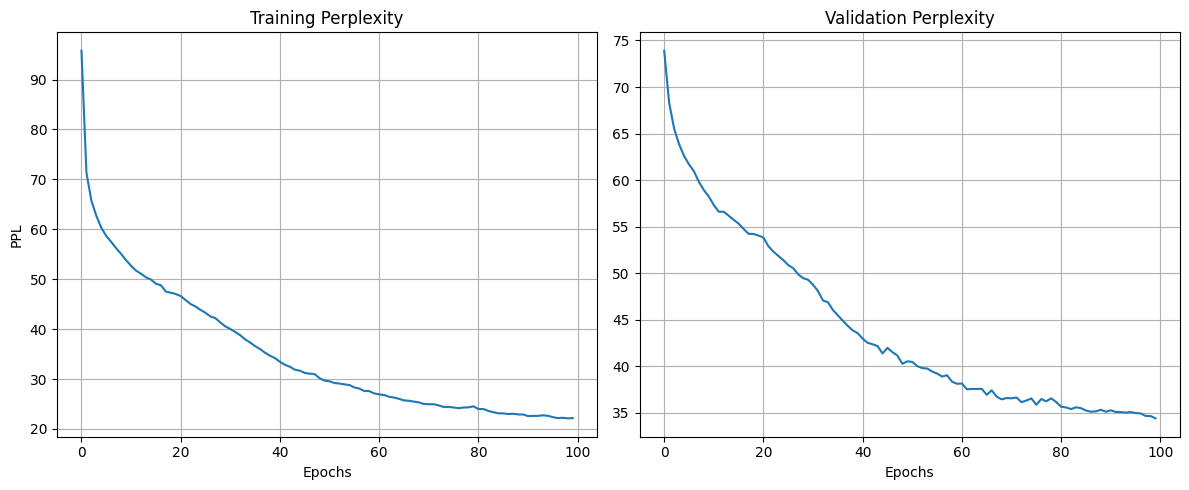

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_ppl)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel('PPL')
axes[0].set_title(f"Training Perplexity")
axes[0].grid(True)

axes[1].plot(val_ppl)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(f'Minimal perplexity: {min(val_ppl):.2f} - achieved at the epoch {val_ppl.index(min(val_ppl))+1}')

---
### Testing the model
#### Text generation

In [ ]:
def text_generation(_text:str, _model=model, _vocab=vocab, _max_lenght:int=10):

  _text = _text.strip().lower().split()

  _model.eval()

  vocab_2 = {idx: word for word, idx in _vocab.items()}

  context = [_vocab.get(word, 0) for word in _text]

  context = context[-5:]
  if len(context) < 5:

    context = [0] * (5 - len(context)) + context

  generated = context.copy()

  for _ in range(_max_lenght):

    context_tensor = torch.tensor([context], dtype=torch.long).to(device)

    with torch.no_grad():
      logits = _model(context_tensor)

    token = torch.argmax(logits.squeeze(), dim=-1).item()

    if token == 0:
      continue

    generated.append(token)
    context = generated[-5:]

  return ' '.join([vocab_2.get(token, '<UKN>') for token in generated])

#### Loading parameters

In [ ]:
best_param_path = r'ia368_act2_best_param.pt'
params = torch.load(best_param_path, map_location=device)

In [ ]:
model = LanguageModel()
model.load_state_dict(params)

SELF-ATTENTION MODO = MATRICIAL


<All keys matched successfully>

#### Testing the model result

In [ ]:
text_generation('a vida é uma grande', _model=model.to(device), _max_lenght=100)

'a vida é uma grande vantagem de não ter sido mais difícil que o governo , sem nenhuma outra coisa . Não se falou de uma ou duas vezes , e , se ela não se pode chamar um médico . Maria Benedita , foi uma grande vantagem de não ter sido mais difícil que o governo , sem nenhuma outra coisa . Não se falou de uma ou duas vezes , e , se ela não se pode chamar um médico . Maria Benedita , foi uma grande vantagem de não ter sido mais difícil que o governo , sem nenhuma outra coisa .'